In [33]:
!pip install ultralytics opencv-python

In [34]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image as PILImage
from IPython.display import display, HTML, clear_output
import time

disp = display("", display_id=True)
model = YOLO("yolo26n.pt")

''

In [35]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      video.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js("takePhoto({})".format(quality))
    return data

In [36]:
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

In [43]:
checklist_items = ["cell phone", "bottle", "book"]

In [38]:
def check_checklist(results):
    detected = {item: False for item in checklist_items}
    for box in results.boxes:
        cls = int(box.cls[0])
        label = model.names[cls]
        if label in checklist_items:
            detected[label] = True
    return detected

In [39]:
def draw_detections(img, results):
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = model.names[cls]

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{label} {conf:.2f}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return img

In [40]:
def draw_checklist_status(img, detected):
    y_offset = 30
    for item, found in detected.items():
        status = "OK" if found else "MISSING"
        color = (0, 255, 0) if found else (0, 0, 255)
        cv2.putText(img, f"{item}: {status}", (10, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        y_offset += 25
    return img

In [41]:
def start_streaming_checklist():
    while True:
        js = take_photo()
        img = js_to_image(js)

        results = model(img)[0]

        detected = check_checklist(results)

        img = draw_detections(img, results)
        img = draw_checklist_status(img, detected)

        clear_output(wait=True)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(img_rgb))

        missing = [item for item, found in detected.items() if not found]
        if missing:
            print(f"⚠️ Belum kedeteksi: {', '.join(missing)}")
        else:
            print("✅ Semua barang lengkap!")

        time.sleep(0.1)

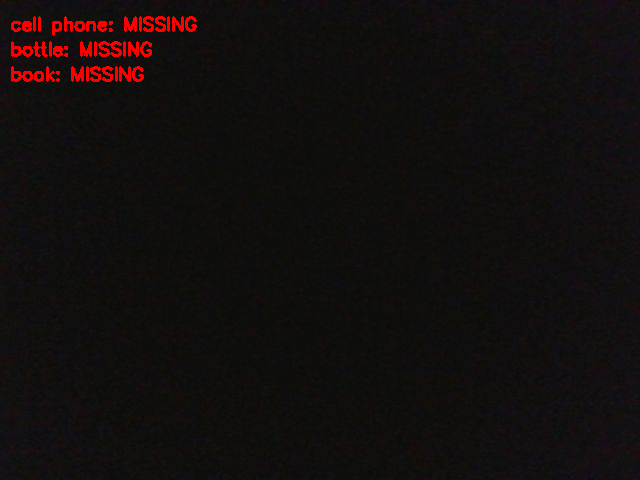

⚠️ Belum kedeteksi: cell phone, bottle, book


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [44]:
start_streaming_checklist()